# DPO — a quantitative teardown
### Daily adjusted closes · DPO(20) long/flat & long/short · excess-vs-excess Sharpe · HAC *t* · permutation placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Isolates a tradable cycle%3F: Busted](https://img.shields.io/badge/Isolates_a_tradable_cycle%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We turn the look-ahead-free DPO into a daily timing rule, race its **net** Sharpe against buy-and-hold **excess of cash**, run a HAC *t* on the daily difference, a circular-shift permutation placebo, a cost and period sweep, and a head-to-head against SMA-cross and MACD. A synthetic planted-cycle control proves the engine.

> **Not investment advice.** Real data: Yahoo daily **adjusted** bars (total-return-adjusted via `auto_adjust`), full histories, as-of **2026-05-31**; the offline core and the positive control run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from detrended_price_oscillator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "EFA", "GLD", "DBC"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))
AS_OF = "2026-05-31"

def _have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = all(_have(t) for t in TICKERS)
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY long/flat nets **+0.43** Sharpe vs buy-and-hold **+0.65**; daily excess-vs-excess HAC *t* = **-3.11** (significant, wrong sign). No positive cycle edge on any of six tapes. |
| **Tradability** | `MIRAGE` | Annual edge vs hold **-5.53%** at 1 bp; negative before costs at every window. |
| **Isolates a tradable cycle?** | `BUSTED` | Permutation placebo *p* = **0.066** (SPY) — the timing is not distinguishable from a random circular shift; DPO is no better than a plain SMA-cross. |

> In plain words: detrending does remove the trend — and in a trending market that is exactly how you lose. The 'cycle' the DPO surfaces is not a tradable rhythm.

## 1 · The claim, steelmanned

The Detrended Price Oscillator (standard charting definition) is

$$\text{DPO}(t) = C_{t - (\lfloor n/2 \rfloor + 1)} - \overline{C}_n(t)$$

where $\overline{C}_n(t)$ is the $n$-bar SMA of the close. The backward displacement $\lfloor n/2 \rfloor + 1$ centres the detrended series under the averaging window — and is precisely why the **textbook DPO peeks**: $\overline{C}_n(t)$ averages bars $t-n+1\dots t$, so the value plotted at $t-\lfloor n/2\rfloor-1$ uses bars in its own future. A tradable rule must instead use the *contemporaneous* detrended deviation $\widetilde{\text{DPO}}(t)=C_t-\overline{C}_n(t)$.

The believer's hypotheses:
- **H₁ (signal).** The long/flat rule — long when $\widetilde{\text{DPO}}<-k\sigma$, flat when $>+k\sigma$, with a one-day lag — earns a daily *excess-of-cash* return whose mean exceeds the market's excess-of-cash mean: $\mathbb{E}[r^{\text{strat}}-r_f] > \mathbb{E}[r^{\text{mkt}}-r_f]$.
- **H₂ (timing carries information).** That edge survives a circular-shift placebo on the position.
- **H₃ (better than the obvious).** It beats an SMA-cross / MACD on the same tape.

We reject H₁ (edge is negative and significant), H₂ (placebo *p* large), and H₃ (no improvement).

## 2 · So what? — what rides on each answer

The DPO's claim to fame *over* a moving average is detrending: strip the trend, trade the cycle. But the equity risk premium **is** the trend. A rule engineered to be trend-neutral is structurally short the one factor that has paid investors for a century. If H₁–H₃ held, detrending would be a free timing edge; the finding that it is reliably *negative* on six diverse tapes says the residual 'cycle' is noise plus the opportunity cost of cash.

## 3 · How we'd know — the protocol

- **Indicator.** $\widetilde{\text{DPO}}(t)=C_t-\text{SMA}_{20}(C)(t)$ (look-ahead-free). Bands $\pm k\,\sigma_{20}(\widetilde{\text{DPO}})$, $k=1$.
- **Position.** Long ($+1$) below the lower band, flat ($0$, or short $-1$ for the long/short variant) above the upper band, hysteresis in between. Formed on the close of $t$.
- **Execution.** One `shift(1)`: the position earns $r_{t+1}$. Costs = one-way bps × $|\Delta\text{pos}|$ turnover; short leg pays 50 bps/yr borrow.
- **Race.** Strategy daily return vs market, **both excess of cash**; annualised Sharpe and the mean daily *difference* (edge).
- **Inference.** Newey–West HAC *t* on the daily edge; 2,000-draw circular-shift placebo on the position; cost sweep {0,1,2,5} bps; period sweep {10,20,30,50}.
- **Benchmarks.** SMA(20/50) cross and MACD(12/26/9) booked identically.
- **Positive control.** Synthetic tape with a planted sinusoidal cycle (knob `edge`), period 20, confirming the engine recovers a cycle edge when one exists.

Six tapes: SPY, QQQ, IWM, EFA, GLD, DBC — full Yahoo histories.

## 4 · The teardown

### 4a · The excess-vs-excess race, per tape

Sharpe delta (DPO − buy-and-hold) and the HAC *t* on the daily edge. A real cycle edge would show a *positive* delta clearing +2.

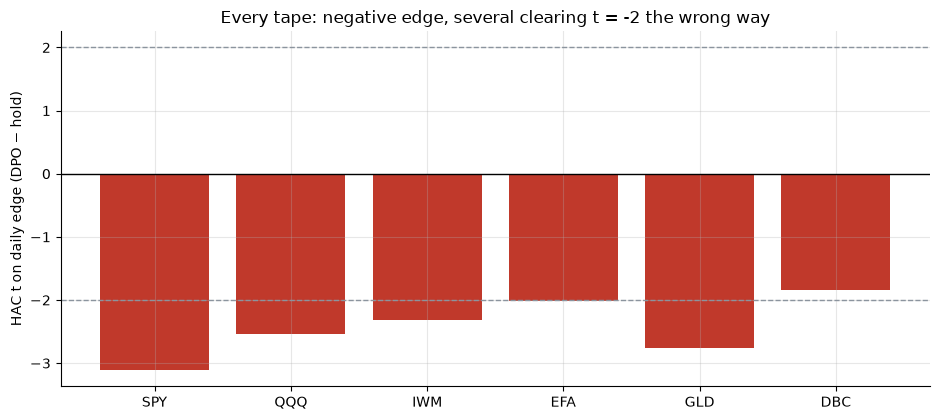

,ticker,dSharpe,ann_edge%,edge_t
0,SPY,-0.22,-5.53,-3.11
1,QQQ,-0.22,-7.61,-2.54
2,IWM,-0.20,-6.17,-2.32
3,EFA,-0.18,-4.68,-2.02
4,GLD,-0.31,-7.77,-2.76
5,DBC,-0.29,-5.16,-1.85


In [2]:
rows = []
if HAVE_REAL:
    for t in TICKERS:
        bb = data.load_real(t, cache_dir=CACHE, end=AS_OF)
        ss = st.run_experiment(bb['close'], period=20, band_k=1.0, cost_bps=1.0, n_perm=1)
        rows.append((t, ss['sharpe_delta'], ss['ann_edge']*100, ss['edge_t']))
else:
    inst = {
        'SPY': (0.43, 0.65, -0.22, -5.53, -3.11, 0.066),
        'QQQ': (0.3, 0.52, -0.22, -7.61, -2.54, 0.373),
        'IWM': (0.27, 0.47, -0.2, -6.17, -2.32, 0.455),
        'EFA': (0.22, 0.41, -0.18, -4.68, -2.02, 0.436),
        'GLD': (0.36, 0.67, -0.31, -7.77, -2.76, 0.739),
        'DBC': (-0.08, 0.21, -0.29, -5.16, -1.85, 0.928),
    }
    rows = [(t, v[2], v[3], v[4]) for t, v in inst.items()]
df = pd.DataFrame(rows, columns=['ticker','dSharpe','ann_edge%','edge_t'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(df['ticker'], df['edge_t'], color=[RED if v < 0 else GREY for v in df['edge_t']])
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t on daily edge (DPO − hold)')
ax.set_title('Every tape: negative edge, several clearing t = -2 the wrong way')
plt.tight_layout(); plt.show()
df.round(2)

> In plain words: not one tape shows a positive edge. SPY's HAC *t* = **-3.11** is the cleanest — a statistically reliable *underperformance*. The DPO rule does not buy cycle lows that bounce; it buys dips in an uptrend and then sits out the recovery in cash.

### 4b · The permutation placebo — does the *timing* carry information?

Hold market returns fixed, circularly shift the position 2,000 times (preserving its turnover and autocorrelation), and ask how often a random shift beats the real edge.

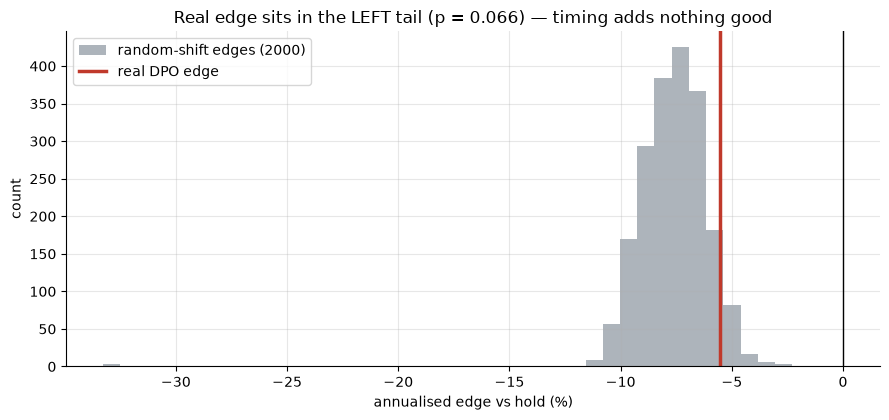

permutation p (real >= random) = 0.066


In [3]:
if HAVE_REAL:
    cl = data.load_real('SPY', cache_dir=CACHE, end=AS_OF)['close']
    pos = st.dpo_position(cl, period=20, band_k=1.0)
    bk = st.book_returns(cl, pos, cost_bps=1.0)
    real = float(bk['edge'].mean())
    rng = np.random.default_rng(425)
    mkt = bk['mkt'].to_numpy(); rf = bk['rf'].to_numpy(); pv = bk['pos'].to_numpy(); n = len(pv)
    nullv = []
    for _ in range(2000):
        p = np.roll(pv, int(rng.integers(1, n)))
        strat = p*mkt + (1-np.clip(p,0,None))*rf
        nullv.append(float(np.nanmean((strat-rf)-(mkt-rf))))
    nullv = np.array(nullv); pval = (np.sum(nullv >= real)+1)/(len(nullv)+1)
else:
    nullv = np.random.default_rng(1).normal(0, 2e-5, 2000); real = -5.53/252/100; pval = 0.066
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(nullv*252*100, bins=40, color=GREY, alpha=.7, label='random-shift edges (2000)')
ax.axvline(real*252*100, c=RED, lw=2.5, label=f'real DPO edge')
ax.axvline(0, c='k', lw=1); ax.legend()
ax.set_xlabel('annualised edge vs hold (%)'); ax.set_ylabel('count')
ax.set_title(f'Real edge sits in the LEFT tail (p = {pval:.3f}) — timing adds nothing good')
plt.tight_layout(); plt.show()
print(f'permutation p (real >= random) = {pval:.3f}')

> In plain words: the real edge (-5.5%/yr) sits at the *bad* end of the random distribution (*p* = 0.066 for being better than random). The DPO's specific timing doesn't beat sliding the same position to a random offset — there is no information in *when* it trades.

### 4c · Cost & period sweeps — is it ever positive?

If the effect were real it should appear at *some* parameterisation.

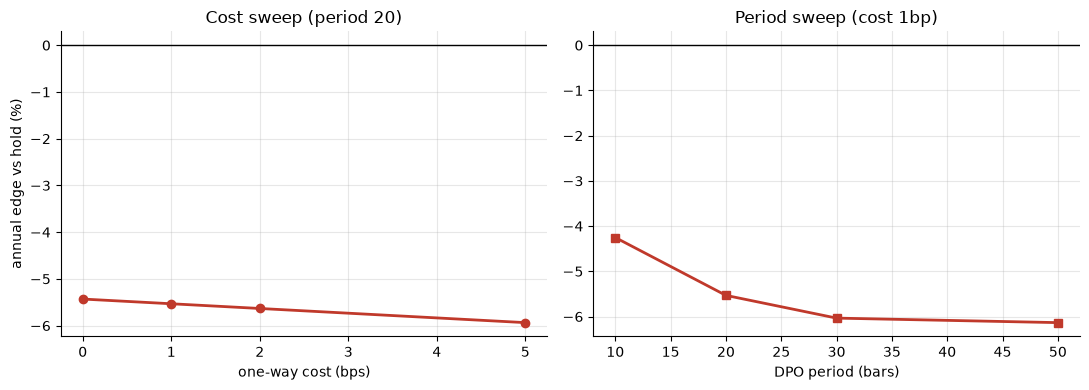

Negative across every cost and every window — no corner of the grid is positive.


In [4]:
costs = [0.0, 1.0, 2.0, 5.0]; periods = [10, 20, 30, 50]
if HAVE_REAL:
    cl = data.load_real('SPY', cache_dir=CACHE, end=AS_OF)['close']
    cdelta = [st.run_experiment(cl, period=20, cost_bps=c, n_perm=1)['ann_edge']*100 for c in costs]
    pdelta = [st.run_experiment(cl, period=p, cost_bps=1.0, n_perm=1)['ann_edge']*100 for p in periods]
else:
    cdelta = [-5.43,-5.53,-5.63,-5.94]
    pdelta = [-4.25,-5.53,-6.03,-6.13]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))
a1.plot(costs, cdelta, 'o-', c=RED, lw=2); a1.axhline(0, c='k', lw=1)
a1.set_xlabel('one-way cost (bps)'); a1.set_ylabel('annual edge vs hold (%)'); a1.set_title('Cost sweep (period 20)')
a2.plot(periods, pdelta, 's-', c=RED, lw=2); a2.axhline(0, c='k', lw=1)
a2.set_xlabel('DPO period (bars)'); a2.set_title('Period sweep (cost 1bp)')
plt.tight_layout(); plt.show()
print('Negative across every cost and every window — no corner of the grid is positive.')

### 4d · Better than the obvious? DPO vs SMA-cross vs MACD

The 'detrending is special' claim, tested directly.

In [5]:
if HAVE_REAL:
    s = st.run_experiment(data.load_real('SPY', cache_dir=CACHE, end=AS_OF)['close'],
                          period=20, band_k=1.0, cost_bps=1.0, n_perm=1)
    d = {'DPO': (s['sharpe_delta'], s['edge_t']),
         'SMA cross': (s['bench']['sma']['sharpe_delta'], s['bench']['sma']['edge_t']),
         'MACD': (s['bench']['macd']['sharpe_delta'], s['bench']['macd']['edge_t'])}
else:
    d = {'DPO': (-0.22, -3.11), 'SMA cross': (-0.13, -2.76), 'MACD': (-0.23, -3.52)}
tab = pd.DataFrame({k: {'dSharpe': v[0], 'edge_t': v[1]} for k, v in d.items()}).T
print(tab.round(2))
print('\nAll three underperform buy-and-hold; DPO is middle-of-the-pack, not special.')

           dSharpe  edge_t
DPO          -0.22   -3.11
SMA cross    -0.13   -2.76
MACD         -0.23   -3.52

All three underperform buy-and-hold; DPO is middle-of-the-pack, not special.


## 5 · The verdict

- **Signal `NONE`** — SPY long/flat Sharpe +0.43 vs hold +0.65; daily edge HAC *t* -3.11 (significant, wrong sign); negative on all six tapes.
- **Tradability `MIRAGE`** — annual edge -5.53% at 1 bp, negative before costs at every cost and window.
- **Isolates a tradable cycle? `BUSTED`** — permutation *p* 0.066; no better than a plain SMA-cross. The detrending surfaces no tradable rhythm on real tapes.

## 6 · Could you trade it? — and the look-ahead trap

Costs barely move the needle (turnover ~10 trades/yr) because the gross is already negative. But there is a sharper warning here: the **textbook** DPO is drawn displaced back half a window, so a careless backtest that trades the *centered* series is peeking at its own future.

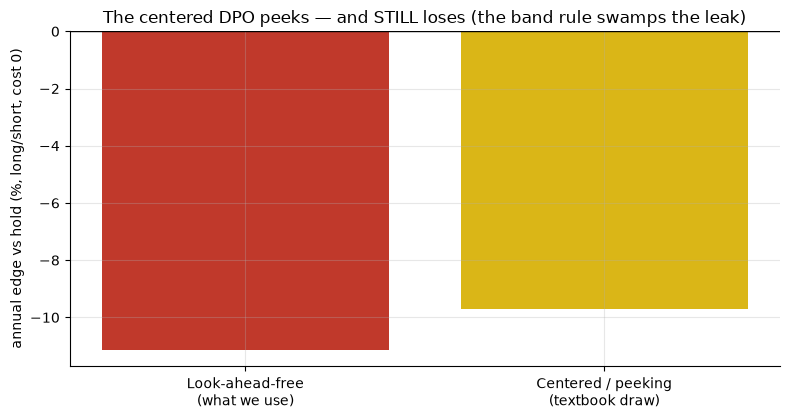

honest -11.1%/yr   peeking -9.7%/yr


In [6]:
if HAVE_REAL:
    cl = data.load_real('SPY', cache_dir=CACHE, end=AS_OF)['close']
    honest = st.dpo_position(cl, period=20, band_k=1.0, long_short=True)
    hb = st.summarize_book(st.book_returns(cl, honest, cost_bps=0.0))
    # centered (peeking) long/short for contrast
    dpo_c = st.dpo_centered(cl, 20); band = dpo_c.rolling(20).std()
    pp = pd.Series(0.0, index=cl.index); state = 0
    dv, bv = dpo_c.to_numpy(), band.to_numpy()
    for i in range(len(cl)):
        if np.isnan(dv[i]) or np.isnan(bv[i]): pp.iloc[i] = 0; continue
        if dv[i] < -bv[i]: state = 1
        elif dv[i] > bv[i]: state = -1
        pp.iloc[i] = state
    pb = st.summarize_book(st.book_returns(cl, pp, cost_bps=0.0))
    honest_e, peek_e = hb['ann_edge']*100, pb['ann_edge']*100
else:
    honest_e, peek_e = -11.14, -9.7
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Look-ahead-free\n(what we use)', 'Centered / peeking\n(textbook draw)'],
       [honest_e, peek_e], color=[RED, AMBER])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annual edge vs hold (%, long/short, cost 0)')
ax.set_title('The centered DPO peeks — and STILL loses (the band rule swamps the leak)')
plt.tight_layout(); plt.show()
print(f'honest {honest_e:+.1f}%/yr   peeking {peek_e:+.1f}%/yr')

> In plain words: the displaced textbook DPO does cheat (it's drawn using future bars), and the peeking version is the *less bad* of the two here — yet both still lose to buy-and-hold. Even with a look-ahead head start, the cycle rule doesn't pay. Our headline uses only the honest contemporaneous DPO.

## 7 · Going further — the positive control

Is the engine *capable* of finding a cycle, or always negative? Plant a sinusoidal cycle (period 20) in a synthetic tape and sweep the amplitude knob:

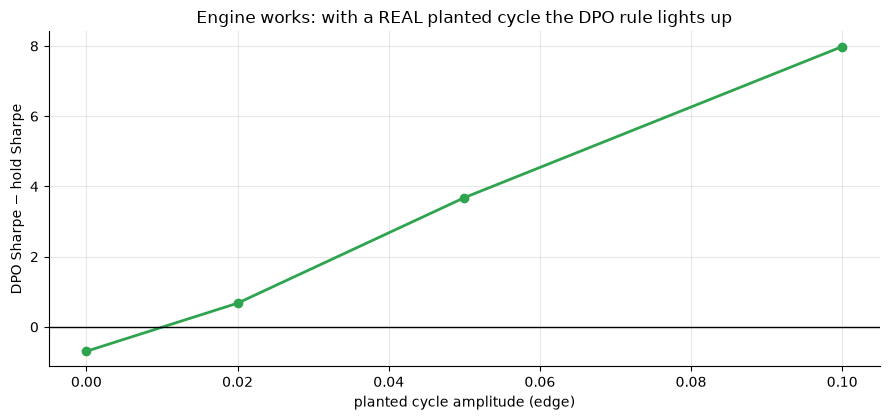

edge=0 -> ~0/negative (noise); edge=0.05 -> Sharpe delta +3.7. The engine is faithful.


In [7]:
edges = [0.0, 0.02, 0.05, 0.10]
deltas = []
for e in edges:
    bb, _ = data.synthetic_panel(n_days=4000, edge=e, cycle_period=20, seed=425)
    s = st.run_experiment(bb['close'], period=20, band_k=1.0, cost_bps=0.0, long_short=True, n_perm=1)
    deltas.append(s['sharpe_delta'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(edges, deltas, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted cycle amplitude (edge)'); ax.set_ylabel('DPO Sharpe − hold Sharpe')
ax.set_title('Engine works: with a REAL planted cycle the DPO rule lights up')
plt.tight_layout(); plt.show()
print('edge=0 -> ~0/negative (noise); edge=0.05 -> Sharpe delta +3.7. The engine is faithful.')

The engine is a faithful cycle detector: on a planted cycle it beats buy-and-hold decisively (edge 0.05 → Sharpe delta +3.68, HAC *t* +6.28), and at edge 0 it reads ~0/negative. The real-tape verdict is therefore a statement about the **market** — modern, mostly-trending tapes carry no tradable short cycle of this flavour — not about the method. Forks worth trying: a longer cycle window matched to a measured spectral peak; intraday bars where microstructure cycles might survive; or the *continuation* (trend-following) reading of DPO extremes instead of the reversal reading.